### Load data

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
#from sklearn.decomposition import PCA
import scipy.signal as signal
import statsmodels.api as sm
import pandas as pd
from seaborn import regplot
from seaborn import heatmap

In [2]:
def weight_by_latitude(da):
    """Weight data array by cosine of latitude."""
    weights = np.cos(np.deg2rad(da['latitude']))
    weighted_da = da * weights
    return weighted_da


def reshape_to_2d(da):
    """Reshape (lat, lon, sample) data into 2D matrix (space x sample)."""
    space_dim = da['latitude'].size * da['longitude'].size
    ##modify here likely!
    reshaped = da.stack(space=('latitude', 'longitude')).transpose('sample', 'space')
    return reshaped


def compute_covariance_matrix(reshaped_da):
    """Compute the covariance matrix of the data."""
    data = reshaped_da.values
    data = data - np.nanmean(data, axis=0)  # Centering the data
    covariance_matrix = np.cov(data.T)
    return covariance_matrix


def perform_svd(cov_matrix):
    """Perform SVD on the covariance matrix."""
    U, S, Vt = np.linalg.svd(cov_matrix)
    return U, S, Vt


def plot_first_principal_component(reshaped_da, Vt):
    """Plot the first principal component as a map."""
    first_pc = Vt[0, :] #first eigenvector with largest eigenvalue
    pc_map = reshaped_da.isel(time=0).copy() #.isel selects the i you give, make a copy of given array at i
    pc_map.values = first_pc #change the values from before to the first_pc values
    pc_map_unstacked = pc_map.unstack('space')

    plt.figure(figsize=(8, 5))
    pc_map_unstacked.plot(cmap='RdBu')
    plt.title("First Principal Component (Spatial Pattern)")
    plt.show()

    return pc_map_unstacked


def compute_zonal_mean(pc_map_unstacked):
    """Compute the zonal mean of the first principal component map."""
    zonal_mean = pc_map_unstacked.mean(dim='longitude')
    return zonal_mean


def make_zonal_mean_map(zonal_mean, da):
    """Create a zonal mean map, assigning each longitude the same value."""
    zonal_map = xr.zeros_like(da.isel(time=0)) #blank map with same dimensions as da
    for lon in zonal_map['longitude']:
        zonal_map.loc[{'longitude': lon}] = zonal_mean #assign zonal mean value to each longitude
    return zonal_map


def regress_onto_zonal_mean_map(da, zonal_map):
    """Regress original data onto the zonal mean map (time series of coefficients)."""
#flattening data
    zonal_map_flat = zonal_map.stack(space=('latitude', 'longitude')).values
    data_flat = da.stack(space=('latitude', 'longitude')).transpose('sample', 'space').values
#detrending by removing mean
    zonal_map_flat = zonal_map_flat - np.nanmean(zonal_map_flat)
    data_flat = data_flat - np.nanmean(data_flat, axis=0)

    regression_coefficients = np.dot(data_flat, zonal_map_flat) / np.dot(zonal_map_flat, zonal_map_flat)

    return regression_coefficients


def plot_regression_coefficients(time, regression_coefficients):
    """Plot regression coefficients over time."""
    plt.figure(figsize=(8, 5))
    plt.plot(time, regression_coefficients, label='Regression Coefficients')
    plt.xlabel('Time')
    plt.ylabel('Coefficient')
    plt.title('Regression Coefficients Over Time')
    plt.grid()
    plt.show()
        


def seasonal_average(da):
    da2=da.groupby('time.year').mean('time')
    return(da2)

def stdize_ssavg(da):
    da2=(da-da.mean())/da.std()
    return da2

## Handling seasonal forecasts

In [3]:
hc=xr.open_dataset('/climca/data/SEAS5_SA/data/seas5_single_levels_06-12month_1-6leadtimemonth.nc') #variable name is t2m

In [4]:
import xarray as xr
import pandas as pd
import numpy as np
import glob

In [5]:
# Path to your NetCDF file
DATADIR='/climca/data/SEAS5_SA/data'
file_new = f"{DATADIR}/seas5_single_levels_06-12month_1-6leadtimemonth.nc"
# Open the dataset
# chunks is useful because your dataset is huge.
# It avoids loading everything into memory immediately.

ds=xr.open_dataset(file_new, chunks={
        "number": 1,
        "forecast_reference_time": 10,
        "forecastMonth": 6
    })

u_data=xr.open_dataset(DATADIR+'/seas5_pressure_levels_wind_06-12month_1-6leadtime_month.nc', 
                       chunks={'number':1, 'forecast_reference_time':10, 'forecastMonth':6})
z500_data=xr.open_dataset(DATADIR+'/seas5_pressure_levels_06-12month_1-6leadtimemonth.nc', 
                          chunks={'number':1, 'forecast_reference_time':10, 'forecastMonth':6})

print(u_data)
print(z500_data)

<xarray.Dataset> Size: 47GB
Dimensions:                  (number: 51, forecast_reference_time: 292,
                              forecastMonth: 6, pressure_level: 2,
                              latitude: 181, longitude: 360)
Coordinates:
  * number                   (number) int64 408B 0 1 2 3 4 5 ... 46 47 48 49 50
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 2kB 198...
  * forecastMonth            (forecastMonth) int64 48B 1 2 3 4 5 6
  * pressure_level           (pressure_level) float64 16B 850.0 50.0
  * latitude                 (latitude) float64 1kB 90.0 89.0 ... -89.0 -90.0
  * longitude                (longitude) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
Data variables:
    u                        (number, forecast_reference_time, forecastMonth, pressure_level, latitude, longitude) float32 47GB dask.array<chunksize=(1, 10, 6, 1, 46, 90), meta=np.ndarray>
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescri

/tmp/ipykernel_1894345/4272456184.py:8: UserWarning: The specified chunks separate the stored chunks along dimension "number" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds=xr.open_dataset(file_new, chunks={
/tmp/ipykernel_1894345/4272456184.py:8: UserWarning: The specified chunks separate the stored chunks along dimension "forecast_reference_time" starting at index 10. This could degrade performance. Instead, consider rechunking after loading.
  ds=xr.open_dataset(file_new, chunks={
/tmp/ipykernel_1894345/4272456184.py:14: UserWarning: The specified chunks separate the stored chunks along dimension "number" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  u_data=xr.open_dataset(DATADIR+'/seas5_pressure_levels_wind_06-12month_1-6leadtime_month.nc',
/tmp/ipykernel_1894345/4272456184.py:14: UserWarning: The specified chunks separate the stored chunks along dimension "forecast_referenc

In [6]:
u_data

<xarray.Dataset> Size: 47GB
Dimensions:                  (number: 51, forecast_reference_time: 292,
                              forecastMonth: 6, pressure_level: 2,
                              latitude: 181, longitude: 360)
Coordinates:
  * number                   (number) int64 408B 0 1 2 3 4 5 ... 46 47 48 49 50
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 2kB 198...
  * forecastMonth            (forecastMonth) int64 48B 1 2 3 4 5 6
  * pressure_level           (pressure_level) float64 16B 850.0 50.0
  * latitude                 (latitude) float64 1kB 90.0 89.0 ... -89.0 -90.0
  * longitude                (longitude) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
Data variables:
    u                        (number, forecast_reference_time, forecastMonth, pressure_level, latitude, longitude) float32 47GB dask.array<chunksize=(1, 10, 6, 1, 46, 90), meta=np.ndarray>
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-03T21:14 GRIB to CDM+CF via cfgrib-0.9.1...

In [7]:
# ------------------------------------------------------------
# Make sure we have valid_time
# ------------------------------------------------------------
# valid_time = real calendar month of the forecast
#
# Example:
# forecast_reference_time = 1981-09-01
# forecastMonth = 1 -> valid_time = 1981-09-01
# forecastMonth = 2 -> valid_time = 1981-10-01
# forecastMonth = 3 -> valid_time = 1981-11-01
# forecastMonth = 4 -> valid_time = 1981-12-01
# forecastMonth = 5 -> valid_time = 1982-01-01
# forecastMonth = 6 -> valid_time = 1982-02-01

#For instance for a forecast with start date on the 1st May, forecastMonth=1 is May,
#  and for a forecast with start date on 17th April, forecastMonth=1 would also be May. 
# This is more coherent and avoids the ambiguity described above.
def make_valid_time(ds):
    if "valid_time" in ds.data_vars:
        # Sometimes valid_time exists but is stored as a data variable.
        # We promote it to a coordinate.
        ds = ds.set_coords("valid_time")


    elif "valid_time" not in ds.coords:
        # If valid_time does not exist, we create it manually.

        init_times = pd.to_datetime(ds["forecast_reference_time"].values)
        lead_months = ds["forecastMonth"].values

        valid_times = []

        for init in init_times:
            valid_times_this_init = []

            for lead in lead_months:
                this_valid_time = init + pd.DateOffset(months=int(lead) - 1)
                valid_times_this_init.append(this_valid_time)

            valid_times.append(valid_times_this_init)

        valid_times = np.array(valid_times, dtype="datetime64[ns]")

        ds = ds.assign_coords(
            valid_time=(
                ("forecast_reference_time", "forecastMonth"),
                valid_times
            )
        )

    print(ds["valid_time"])
    return ds

ds=make_valid_time(ds)
u_data=make_valid_time(u_data)
z500_data=make_valid_time(z500_data)

<xarray.DataArray 'valid_time' (forecast_reference_time: 292, forecastMonth: 6)> Size: 14kB
array([['1981-06-01T00:00:00.000000000', '1981-07-01T00:00:00.000000000',
        '1981-08-01T00:00:00.000000000', '1981-09-01T00:00:00.000000000',
        '1981-10-01T00:00:00.000000000', '1981-11-01T00:00:00.000000000'],
       ['1981-07-01T00:00:00.000000000', '1981-08-01T00:00:00.000000000',
        '1981-09-01T00:00:00.000000000', '1981-10-01T00:00:00.000000000',
        '1981-11-01T00:00:00.000000000', '1981-12-01T00:00:00.000000000'],
       ['1981-08-01T00:00:00.000000000', '1981-09-01T00:00:00.000000000',
        '1981-10-01T00:00:00.000000000', '1981-11-01T00:00:00.000000000',
        '1981-12-01T00:00:00.000000000', '1982-01-01T00:00:00.000000000'],
       ...,
       ['2022-08-01T00:00:00.000000000', '2022-09-01T00:00:00.000000000',
        '2022-10-01T00:00:00.000000000', '2022-11-01T00:00:00.000000000',
        '2022-12-01T00:00:00.000000000', '2023-01-01T00:00:00.000000000'],
    

In [8]:
print(u_data.valid_time.forecastMonth.values)

#this shows first year 1981, init June + 6 months
print(u_data.valid_time.values[0])
#this shows first year 1981, init July + 6 months
print(u_data.valid_time.values[1])

months = ds.forecast_reference_time.dt.month.values

print(np.unique(months, return_counts=True))

[1 2 3 4 5 6]
['1981-06-01T00:00:00.000000000' '1981-07-01T00:00:00.000000000'
 '1981-08-01T00:00:00.000000000' '1981-09-01T00:00:00.000000000'
 '1981-10-01T00:00:00.000000000' '1981-11-01T00:00:00.000000000']
['1981-07-01T00:00:00.000000000' '1981-08-01T00:00:00.000000000'
 '1981-09-01T00:00:00.000000000' '1981-10-01T00:00:00.000000000'
 '1981-11-01T00:00:00.000000000' '1981-12-01T00:00:00.000000000']
(array([ 6,  7,  8,  9, 10, 11, 12]), array([42, 42, 42, 42, 42, 41, 41]))


In [9]:
for m in range(1, 13):
    dates = ds.forecast_reference_time.where(
        ds.forecast_reference_time.dt.month == m,
        drop=True
    )
    print(m, dates.values[:5])

1 []
2 []
3 []
4 []
5 []
6 ['1981-06-01T00:00:00.000000000' '1982-06-01T00:00:00.000000000'
 '1983-06-01T00:00:00.000000000' '1984-06-01T00:00:00.000000000'
 '1985-06-01T00:00:00.000000000']
7 ['1981-07-01T00:00:00.000000000' '1982-07-01T00:00:00.000000000'
 '1983-07-01T00:00:00.000000000' '1984-07-01T00:00:00.000000000'
 '1985-07-01T00:00:00.000000000']
8 ['1981-08-01T00:00:00.000000000' '1982-08-01T00:00:00.000000000'
 '1983-08-01T00:00:00.000000000' '1984-08-01T00:00:00.000000000'
 '1985-08-01T00:00:00.000000000']
9 ['1981-09-01T00:00:00.000000000' '1982-09-01T00:00:00.000000000'
 '1983-09-01T00:00:00.000000000' '1984-09-01T00:00:00.000000000'
 '1985-09-01T00:00:00.000000000']
10 ['1981-10-01T00:00:00.000000000' '1982-10-01T00:00:00.000000000'
 '1983-10-01T00:00:00.000000000' '1984-10-01T00:00:00.000000000'
 '1985-10-01T00:00:00.000000000']
11 ['1981-11-01T00:00:00.000000000' '1982-11-01T00:00:00.000000000'
 '1983-11-01T00:00:00.000000000' '1984-11-01T00:00:00.000000000'
 '1985-11-0

['1981-12-01T00:00:00.000000000' '1982-12-01T00:00:00.000000000'
 '1983-12-01T00:00:00.000000000' '1984-12-01T00:00:00.000000000'
 '1985-12-01T00:00:00.000000000']


In [10]:
def make_3_month_block_old(ds, lead_months, block_name):
    """
    Select a 3-month forecast block.

    lead_months can be:
        [1, 2, 3]
        [4, 5, 6]

    block_name is just a label:
        "lead_1_2_3"
        "lead_4_5_6"
    """

    #select requested lead months
    block = ds.sel(forecastMonth=lead_months)

    #save them in new coordinate
    block = block.assign_coords(
        original_forecastMonth=("forecastMonth", lead_months)
    )

    #rename old coordinate to new name
    block = block.rename({"forecastMonth": "season_month"})

    #reset month numbering
    block = block.assign_coords(
        season_month=[1, 2, 3]
    )
    #assign lead block name
    block = block.assign_coords(
        lead_block=block_name
    )

    return block

In [11]:
def season_to_leads(init_month, season_months):
    """
    Convert calendar months to forecast lead months.

    Parameters
    ----------
    init_month : int
        Initialization month (1=Jan, ..., 12=Dec)

    season_months : list
        Calendar months, e.g. [9,10,11] for SON.

    Returns
    -------
    list
        Corresponding forecast lead months.
    """
    leads = []

    for month in season_months:
        lead = (month - init_month+1) % 12
        if lead == 0:
            lead = 12
        leads.append(lead)

    return leads

def make_3_month_block(ds, lead_months, init_month, block_name):

    # Select forecast initializations occurring in this month
    mask = ds.forecast_reference_time.dt.month == init_month

    block = ds.where(mask, drop=True)

    # Select the required forecast leads
    block = block.sel(
        forecastMonth=lead_months
    )

    # Save original lead numbers
    block = block.assign_coords(
        original_forecastMonth=(
            "forecastMonth",
            lead_months
        )
    )

    # Rename lead dimension
    block = block.rename(
        {"forecastMonth": "season_month"}
    )

    # Seasonal positions
    block = block.assign_coords(
        season_month=[1, 2, 3]
    )

    # Create an actual init_month dimension
    block = block.expand_dims(
        init_month=[init_month]
    )

    # Season label
    block = block.assign_coords(
        lead_block=block_name
    )

    return block
spring_leads_list=[]
for init_month in [6,7,8,9]:
    ##spring season block
    lead_months_spring=season_to_leads(init_month=init_month, season_months=[9,10,11])
    print(
        f"init={init_month}: SON leads={lead_months_spring}"
    )

    block_spring=make_3_month_block(ds, lead_months=lead_months_spring, init_month=init_month, block_name='SON_block')
    spring_leads_list.append(block_spring)

summer_leads_list=[]
for init_month in [9,10,11,12]:
    ##summer season block
    lead_months_summer=season_to_leads(init_month=init_month, season_months=[12,1,2])
    print(
        f"init={init_month}: DJF leads={lead_months_summer}"
    )
    block_summer=make_3_month_block(ds, lead_months=lead_months_summer, init_month=init_month, block_name='DJF_block')
    summer_leads_list.append(block_summer)


display(block_spring)

init=6: SON leads=[4, 5, 6]
init=7: SON leads=[3, 4, 5]
init=8: SON leads=[2, 3, 4]
init=9: SON leads=[1, 2, 3]
init=9: DJF leads=[4, 5, 6]
init=10: DJF leads=[3, 4, 5]
init=11: DJF leads=[2, 3, 4]
init=12: DJF leads=[1, 2, 3]


<xarray.Dataset> Size: 7GB
Dimensions:                  (init_month: 1, number: 51,
                              forecast_reference_time: 42, season_month: 3,
                              latitude: 181, longitude: 360)
Coordinates:
  * init_month               (init_month) int64 8B 9
  * number                   (number) int64 408B 0 1 2 3 4 5 ... 46 47 48 49 50
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 336B 19...
  * latitude                 (latitude) float64 1kB 90.0 89.0 ... -89.0 -90.0
  * longitude                (longitude) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
    valid_time               (forecast_reference_time, season_month) datetime64[ns] 1kB ...
    original_forecastMonth   (season_month) int64 24B 1 2 3
  * season_month             (season_month) int64 24B 1 2 3
    lead_block               <U9 36B 'SON_block'
Data variables:
    t2m                      (init_month, number, forecast_reference_time, season_month, latitude, longitude) float32 2GB dask.array<chunksize=(1, 1, 9, 3, 37, 72), meta=np.ndarray>
    msl                      (init_month, number, forecast_reference_time, season_month, latitude, longitude) float32 2GB dask.array<chunksize=(1, 1, 9, 3, 37, 72), meta=np.ndarray>
    sst                      (init_month, number, forecast_reference_time, season_month, latitude, longitude) float32 2GB dask.array<chunksize=(1, 1, 9, 3, 37, 72), meta=np.ndarray>
    tprate                   (init_month, number, forecast_reference_time, season_month, latitude, longitude) float32 2GB dask.array<chunksize=(1, 1, 9, 3, 37, 72), meta=np.ndarray>
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-03T13:40 GRIB to CDM+CF via cfgrib-0.9.1...

In [12]:
ds_3m_SON = xr.concat(
    spring_leads_list,
    dim="init_month")

ds_3m_DJF = xr.concat(
    summer_leads_list,
    dim="init_month")

u_data_3m_SON = xr.concat(
    [make_3_month_block(u_data, season_to_leads(init_month=init_month, season_months=[9,10,11]), init_month=init_month, block_name='SON_block') for init_month in [6,7,8,9]],
    dim="init_month")

u_data_3m_DJF = xr.concat(
    [make_3_month_block(u_data, season_to_leads(init_month=init_month, season_months=[12,1,2]), init_month=init_month, block_name='DJF_block') for init_month in [9,10,11,12]],
    dim="init_month")

#z500_data_3m_SON = xr.concat(
#    [make_3_month_block(z500_data, season_to_leads(init_month=init_month, season_months=[9,10,11]), init_month=init_month) for init_month in [6,7,8,9]],
#    dim="init_month")

#z500_data_3m_DJF = xr.concat(
#    [make_3_month_block(z500_data, season_to_leads(init_month=init_month, season_months=[12,1,2]), init_month=init_month) for init_month in [9,10,11,12]],
#    dim="init_month")


display(ds_3m_SON)

/home/glattus/anaconda3/envs/climate/lib/python3.10/site-packages/dask/array/core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/home/glattus/anaconda3/envs/climate/lib/python3.10/site-packages/dask/array/core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/home/glattus/anaconda3/envs/climate/lib/python3.10/site-packages/dask/array/core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/home/glattus/anaconda3/envs/climate/lib/python3.10/site-packages/dask/array/core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/home/glattus/anaconda3/envs/climate/lib/python3.10/site-packages/dask/array/core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/home/glattus/anaconda3/envs/climate/lib/python3.10/site-packages/dask/array/core.py:5200: PerformanceWarning: Incr

<xarray.Dataset> Size: 107GB
Dimensions:                  (init_month: 4, number: 51,
                              forecast_reference_time: 168, season_month: 3,
                              latitude: 181, longitude: 360)
Coordinates:
  * number                   (number) int64 408B 0 1 2 3 4 5 ... 46 47 48 49 50
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 1kB 198...
  * latitude                 (latitude) float64 1kB 90.0 89.0 ... -89.0 -90.0
  * longitude                (longitude) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
  * season_month             (season_month) int64 24B 1 2 3
  * init_month               (init_month) int64 32B 6 7 8 9
    valid_time               (init_month, forecast_reference_time, season_month) datetime64[ns] 16kB ...
    original_forecastMonth   (init_month, season_month) int64 96B 4 5 6 ... 2 3
    lead_block               <U9 36B 'SON_block'
Data variables:
    t2m                      (init_month, number, forecast_reference_time, season_month, latitude, longitude) float32 27GB dask.array<chunksize=(1, 1, 8, 3, 37, 72), meta=np.ndarray>
    msl                      (init_month, number, forecast_reference_time, season_month, latitude, longitude) float32 27GB dask.array<chunksize=(1, 1, 8, 3, 37, 72), meta=np.ndarray>
    sst                      (init_month, number, forecast_reference_time, season_month, latitude, longitude) float32 27GB dask.array<chunksize=(1, 1, 8, 3, 37, 72), meta=np.ndarray>
    tprate                   (init_month, number, forecast_reference_time, season_month, latitude, longitude) float32 27GB dask.array<chunksize=(1, 1, 8, 3, 37, 72), meta=np.ndarray>
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-03T13:40 GRIB to CDM+CF via cfgrib-0.9.1...

In [13]:
test = ds_3m_SON.isel(
    init_month=3,
    number=0,
    latitude=90,
    longitude=180
)

print(test.valid_time.values)
print(test.original_forecastMonth.values)

[[                          'NaT'                           'NaT'
                            'NaT']
 [                          'NaT'                           'NaT'
                            'NaT']
 [                          'NaT'                           'NaT'
                            'NaT']
 ['1981-09-01T00:00:00.000000000' '1981-10-01T00:00:00.000000000'
  '1981-11-01T00:00:00.000000000']
 [                          'NaT'                           'NaT'
                            'NaT']
 [                          'NaT'                           'NaT'
                            'NaT']
 [                          'NaT'                           'NaT'
                            'NaT']
 ['1982-09-01T00:00:00.000000000' '1982-10-01T00:00:00.000000000'
  '1982-11-01T00:00:00.000000000']
 [                          'NaT'                           'NaT'
                            'NaT']
 [                          'NaT'                           'NaT'
                         

In [14]:
#one sample consists of one ensemble member, one initialization date, one lead block 
#e.g. sample #1234: member 17, initialized 1981-09-01, lead_4_5_6 
# -->season_month=1 -> Dec 1981
# season_month=2 -> Jan 1982
# season_month=3 -> Feb 1982
def create_sample_and_cobmine_seasons(ds_3m_SON, ds_3m_DJF):

    #add season coordinate
    ds_3m_SON = ds_3m_SON.expand_dims(
    season=["SON"]
    )

    ds_3m_DJF = ds_3m_DJF.expand_dims(
        season=["DJF"]
    )

    #create sample multiindex
    ds_3m_SON = ds_3m_SON.stack(
        sample=("init_month", 'season', "forecast_reference_time", "number")
    )
    ds_3m_DJF = ds_3m_DJF.stack(
        sample=("init_month", 'season', "forecast_reference_time", "number")
    )

    

    ds_3m_SON = ds_3m_SON.transpose(
        "sample",
        "season_month",
        "latitude",
        "longitude"
    )

    ds_3m_DJF = ds_3m_DJF.transpose(
        "sample",
        "season_month",
        "latitude",
        "longitude"
    )
    return ds_3m_SON, ds_3m_DJF

ds_3m_list = create_sample_and_cobmine_seasons(ds_3m_SON, ds_3m_DJF)

u50_data_3m_list=create_sample_and_cobmine_seasons(u_data_3m_SON.sel(pressure_level=50), 
                                              u_data_3m_DJF.sel(pressure_level=50))
u850_data_3m_list=create_sample_and_cobmine_seasons(u_data_3m_SON.sel(pressure_level=850), 
                                              u_data_3m_DJF.sel(pressure_level=850))
#z500_data_3m=create_sample_and_cobmine_seasons(z500_data_3m_SON.sel(pressure_level=500), z500_data_3m_DJF.sel(pressure_level=500))

print(u50_data_3m_list[0])

<xarray.Dataset> Size: 27GB
Dimensions:                  (season_month: 3, latitude: 181, longitude: 360,
                              sample: 34272)
Coordinates:
    pressure_level           float64 8B 50.0
  * latitude                 (latitude) float64 1kB 90.0 89.0 ... -89.0 -90.0
  * longitude                (longitude) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
  * season_month             (season_month) int64 24B 1 2 3
    valid_time               (sample, season_month) datetime64[ns] 823kB 1981...
    original_forecastMonth   (sample, season_month) int64 823kB 4 5 6 ... 1 2 3
    lead_block               <U9 36B 'SON_block'
  * sample                   (sample) object 274kB MultiIndex
  * init_month               (sample) int64 274kB 6 6 6 6 6 6 6 ... 9 9 9 9 9 9
  * season                   (sample) object 274kB 'SON' 'SON' ... 'SON' 'SON'
  * forecast_reference_time  (sample) datetime64[ns] 274kB 1981-06-01 ... 202...
  * number                   (sample) int64 274kB 0 1 2 3 4 

In [15]:
def months_to_season_name(months):
    """
    Convert three month numbers into a season name.
    """

    months = tuple(months)

    season_dict = {
        (9, 10, 11): "SON",
        (10, 11, 12): "OND",
        (11, 12, 1): "NDJ",
        (12, 1, 2): "DJF",
        (1, 2, 3): "JFM",
        (2, 3, 4): "FMA",
        (3, 4, 5): "MAM",
        (4, 5, 6): "AMJ",
        (5, 6, 7): "MJJ",
    }

    return season_dict.get(months, "OTHER")

In [16]:
# real_seasons = []
# real_months = []
# season_labels = []

# for i in range(ds_3m.sizes["sample"]):

#     These are the 3 real calendar dates of this sample
#     dates = pd.to_datetime(ds_3m["valid_time"].isel(sample=i).values)

#     Example: [9, 10, 11]
#     months = [int(d.month) for d in dates]

#     Example: [1981, 1981, 1981]
#     years = [int(d.year) for d in dates]

#     season_name = months_to_season_name(months)

#     real_seasons.append(season_name)
#     real_months.append("-".join([f"{m:02d}" for m in months]))

#     if years[0] == years[-1]:
#         label = f"{season_name}_{years[0]}"
#     else:
#         label = f"{season_name}_{years[0]}_{years[-1]}"

#     season_labels.append(label)

# ds_3m = ds_3m.assign_coords(
#     real_season=("sample", real_seasons),
#     real_months=("sample", real_months),
#     season_label=("sample", season_labels)
# )


# u50_data_3m = u50_data_3m.assign_coords(
#     real_season=("sample", real_seasons),
#     real_months=("sample", real_months),
#     season_label=("sample", season_labels)
# )

# u850_data_3m = u850_data_3m.assign_coords(
#     real_season=("sample", real_seasons),
#     real_months=("sample", real_months),
#     season_label=("sample", season_labels)
# )

# z500_data_3m=z500_data_3m.assign_coords(
#     real_season=("sample", real_seasons),
#     real_months=("sample", real_months),
#     season_label=("sample", season_labels))

In [17]:
for i in np.arange(1000,10000,1000):
    print(
        ds_3m_list[0].forecast_reference_time.isel(sample=i).values,
        ds_3m_list[0].init_month.isel(sample=i).values,
        ds_3m_list[0].valid_time.isel(sample=i).values,
        #ds_3m.season.values
    )

1985-09-01T00:00:00.000000000 6 ['NaT' 'NaT' 'NaT']
1990-09-01T00:00:00.000000000 6 ['NaT' 'NaT' 'NaT']
1995-08-01T00:00:00.000000000 6 ['NaT' 'NaT' 'NaT']
2000-08-01T00:00:00.000000000 6 ['NaT' 'NaT' 'NaT']
2005-08-01T00:00:00.000000000 6 ['NaT' 'NaT' 'NaT']
2010-07-01T00:00:00.000000000 6 ['NaT' 'NaT' 'NaT']
2015-07-01T00:00:00.000000000 6 ['NaT' 'NaT' 'NaT']
2020-06-01T00:00:00.000000000 6 ['2020-09-01T00:00:00.000000000' '2020-10-01T00:00:00.000000000'
 '2020-11-01T00:00:00.000000000']
1983-06-01T00:00:00.000000000 7 ['NaT' 'NaT' 'NaT']


In [18]:
SON = ds_3m_list[0].where(ds_3m_list[0]["season"] == "SON", drop=True)

DJF = ds_3m_list[1].where(ds_3m_list[1]["season"] == "DJF", drop=True)


print("SON samples:", SON.sizes["sample"])
print("DJF samples:", DJF.sizes["sample"])
#print("SON + DJF samples:", SON_DJF.sizes["sample"])

SON samples: 34272
DJF samples: 33864


In [19]:
DJF

<xarray.Dataset> Size: 106GB
Dimensions:                  (sample: 33864, season_month: 3, latitude: 181,
                              longitude: 360)
Coordinates:
  * latitude                 (latitude) float64 1kB 90.0 89.0 ... -89.0 -90.0
  * longitude                (longitude) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
  * season_month             (season_month) int64 24B 1 2 3
    valid_time               (sample, season_month) datetime64[ns] 813kB 1981...
    original_forecastMonth   (sample, season_month) int64 813kB 4 5 6 ... 1 2 3
    lead_block               <U9 36B 'DJF_block'
  * sample                   (sample) object 271kB MultiIndex
  * init_month               (sample) int64 271kB 9 9 9 9 9 9 ... 12 12 12 12 12
  * season                   (sample) object 271kB 'DJF' 'DJF' ... 'DJF' 'DJF'
  * forecast_reference_time  (sample) datetime64[ns] 271kB 1981-09-01 ... 202...
  * number                   (sample) int64 271kB 0 1 2 3 4 5 ... 46 47 48 49 50
Data variables:
    t2m                      (sample, season_month, latitude, longitude) float32 26GB dask.array<chunksize=(7, 3, 37, 72), meta=np.ndarray>
    msl                      (sample, season_month, latitude, longitude) float32 26GB dask.array<chunksize=(7, 3, 37, 72), meta=np.ndarray>
    sst                      (sample, season_month, latitude, longitude) float32 26GB dask.array<chunksize=(7, 3, 37, 72), meta=np.ndarray>
    tprate                   (sample, season_month, latitude, longitude) float32 26GB dask.array<chunksize=(7, 3, 37, 72), meta=np.ndarray>
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-03T13:40 GRIB to CDM+CF via cfgrib-0.9.1...

In [20]:
SON_u50 = u50_data_3m_list[0].where(u50_data_3m_list[0]["season"] == "SON", drop=True)

DJF_u50 = u50_data_3m_list[1].where(u50_data_3m_list[1]["season"] == "DJF", drop=True)

#SON_DJF_u50 = u50_data_3m[0].where(
#    u50_data_3m["season"].isin(["SON", "DJF"]),
#    drop=True
#)

SON_u850 = u850_data_3m_list[0].where(u850_data_3m_list[0]["season"] == "SON", drop=True)

DJF_u850 = u850_data_3m_list[1].where(u850_data_3m_list[1]["season"] == "DJF", drop=True)

#SON_DJF_u850 = u850_data_3m.where(
#    u850_data_3m["season"].isin(["SON", "DJF"]),
#    drop=True
#)

#SON_z500 = z500_data_3m.where(z500_data_3m["season"] == "SON", drop=True)

#DJF_z500 = z500_data_3m.where(z500_data_3m["season"] == "DJF", drop=True)

#SON_DJF_z500 = z500_data_3m.where(
#    z500_data_3m["season"].isin(["SON", "DJF"]),
#    drop=True
#)


In [21]:
#for i in range(5):
    #print("sample:", i)
    #print("season:", SON_DJF["season"].isel(sample=i).values)
    #print("label:", SON_DJF["season_label"].isel(sample=i).values)
    #print("lead block:", SON_DJF["lead_block"].isel(sample=i).values)
    #print("init:", SON_DJF["forecast_reference_time"].isel(sample=i).values)
    #print("valid months:", SON_DJF["valid_time"].isel(sample=i).values)
    #print()

In [22]:
SON_u50

<xarray.Dataset> Size: 27GB
Dimensions:                  (sample: 34272, season_month: 3, latitude: 181,
                              longitude: 360)
Coordinates:
    pressure_level           float64 8B 50.0
  * latitude                 (latitude) float64 1kB 90.0 89.0 ... -89.0 -90.0
  * longitude                (longitude) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
  * season_month             (season_month) int64 24B 1 2 3
    valid_time               (sample, season_month) datetime64[ns] 823kB 1981...
    original_forecastMonth   (sample, season_month) int64 823kB 4 5 6 ... 1 2 3
    lead_block               <U9 36B 'SON_block'
  * sample                   (sample) object 274kB MultiIndex
  * init_month               (sample) int64 274kB 6 6 6 6 6 6 6 ... 9 9 9 9 9 9
  * season                   (sample) object 274kB 'SON' 'SON' ... 'SON' 'SON'
  * forecast_reference_time  (sample) datetime64[ns] 274kB 1981-06-01 ... 202...
  * number                   (sample) int64 274kB 0 1 2 3 4 5 ... 46 47 48 49 50
Data variables:
    u                        (sample, season_month, latitude, longitude) float32 27GB dask.array<chunksize=(7, 3, 46, 90), meta=np.ndarray>
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-03T21:14 GRIB to CDM+CF via cfgrib-0.9.1...

In [23]:
SON_mean = SON.mean(dim="season_month")
DJF_mean = DJF.mean(dim="season_month")

SON_u50_mean=SON_u50.mean(dim='season_month')
DJF_u50_mean=DJF_u50.mean(dim='season_month')
#SON_DJF_u50_mean=SON_DJF_u50.mean(dim='season_month')

SON_u850_mean=SON_u850.mean(dim='season_month')
DJF_u850_mean=DJF_u850.mean(dim='season_month')

#SON_z500_mean=SON_z500.mean(dim='season_month')
#DJF_z500_mean=DJF_z500.mean(dim='season_month')

In [24]:
display(DJF_mean['t2m'])

<xarray.DataArray 't2m' (sample: 33864, latitude: 181, longitude: 360)> Size: 9GB
dask.array<mean_agg-aggregate, shape=(33864, 181, 360), dtype=float32, chunksize=(8, 37, 72), chunktype=numpy.ndarray>
Coordinates:
  * latitude                 (latitude) float64 1kB 90.0 89.0 ... -89.0 -90.0
  * longitude                (longitude) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
    lead_block               <U9 36B 'DJF_block'
  * sample                   (sample) object 271kB MultiIndex
  * init_month               (sample) int64 271kB 9 9 9 9 9 9 ... 12 12 12 12 12
  * season                   (sample) object 271kB 'DJF' 'DJF' ... 'DJF' 'DJF'
  * forecast_reference_time  (sample) datetime64[ns] 271kB 1981-09-01 ... 202...
  * number                   (sample) int64 271kB 0 1 2 3 4 5 ... 46 47 48 49 50

# Data preparation

In [25]:
def select_region(ds, lat_min, lat_max, lon_min, lon_max):
    """
    Select a latitude-longitude box.

    Works even if latitude is ordered north-to-south, as in ERA5/SEAS5:
        90, 89, 88, ..., -90

    Longitude in your dataset is 0 to 360.
    So:
        -76 to -70 becomes 284 to 290
        -62 to -49 becomes 298 to 311
    """

    lat = ds["latitude"]

    # If latitude is decreasing: 90, 89, ..., -90
    if lat[0] > lat[-1]:
        lat_slice = slice(lat_max, lat_min)
    else:
        lat_slice = slice(lat_min, lat_max)

    out = ds.sel(
        latitude=lat_slice,
        longitude=slice(lon_min, lon_max)
    )

    return out

def compute_sample_anomaly(ds):
    """
    Compute anomaly across all samples.

    For each grid point:
        anomaly = value - mean over samples

    This keeps all ensemble members and all years.
    """

    return ds - ds.mean(dim="sample")

def detrend_across_time(ds):
    """
    Remove a linear trend across time.

    Important:
    Your dimension is called 'sample', not 'time'.

    Each sample has a coordinate called 'forecast_reference_time'.
    We extract the year from that coordinate and regress each grid point
    against year.

    Because you have 51 ensemble members per year, the same year appears
    many times. That is okay: the trend is fitted across all samples.
    """

    # Extract year from forecast_reference_time
    years = xr.DataArray(
        ds["forecast_reference_time"].dt.year.values,
        dims="sample",
        coords={"sample": ds["sample"]},
        name="year"
    )

    # Center the year to make the regression numerically cleaner
    x = years - years.mean(dim="sample")

    # Output container
    detrended_vars = {}

    for var in ds.data_vars:

        y = ds[var]

        # Mean over sample
        y_mean = y.mean(dim="sample")

        # Linear regression slope:
        # slope = cov(x, y) / var(x)
        slope = ((x * (y - y_mean)).mean(dim="sample")) / ((x ** 2).mean(dim="sample"))

        # Fitted linear trend
        fit = y_mean + slope * x

        # Remove fitted trend
        detrended_vars[var] = y - fit

    out = xr.Dataset(detrended_vars, coords=ds.coords)

    return out


def spatial_average(ds):
    """
    Latitude-weighted spatial average.

    Output:
        one value per sample
    """

    weights = np.cos(np.deg2rad(ds["latitude"]))

    out = ds.weighted(weights).mean(dim=["latitude", "longitude"])

    return out

def standardize(ds):
    """
    Standardize each variable across samples.

    z = value / std

    The mean should already be near zero after anomaly + detrending.
    If you want strict z-score, use:
        (ds - ds.mean("sample")) / ds.std("sample")
    """

    return ds / ds.std(dim="sample")

def process_region(ds_season, lat_min, lat_max, lon_min, lon_max):
    """
    Full pipeline for one region and one season.

    Input:
        ds_season = SON_mean or DJF_mean

    Output:
        standardized anomaly time series for all samples
    """

    # 1. Select region
    region = select_region(
        ds_season,
        lat_min=lat_min,
        lat_max=lat_max,
        lon_min=lon_min,
        lon_max=lon_max
    )

    # 2. Anomaly over samples
    region_an = compute_sample_anomaly(region)

    # 3. Remove linear trend across time/sample
    region_detr = detrend_across_time(region_an)

    # 4. Spatial average
    region_avg = spatial_average(region_detr)

    # 5. Standardize
    region_std = standardize(region_avg)

    return region_std




In [26]:
# Andes
# Original longitude: -76 to -70
# In 0..360: 284 to 290

ANDES = {
    "lat_min": -55,
    "lat_max": -35,
    "lon_min": 284,
    "lon_max": 290,
}


# La Plata
# Original longitude: -62 to -49
# In 0..360: 298 to 311

LA_PLATA = {
    "lat_min": -32,
    "lat_max": -20,
    "lon_min": 298,
    "lon_max": 311,
}

In [27]:
# Andes temperature, SON and DJF
t_Andes_ssavg_SON = process_region(SON_mean[["t2m"]], **ANDES)
t_Andes_ssavg_DJF = process_region(DJF_mean[["t2m"]], **ANDES)

# La Plata temperature, SON and DJF
t_LaPlata_ssavg_SON = process_region(SON_mean[["t2m"]], **LA_PLATA)
t_LaPlata_ssavg_DJF = process_region(DJF_mean[["t2m"]], **LA_PLATA)

In [28]:
print(t_Andes_ssavg_DJF)

<xarray.Dataset> Size: 2MB
Dimensions:                  (sample: 33864)
Coordinates:
    lead_block               <U9 36B 'DJF_block'
  * sample                   (sample) object 271kB MultiIndex
  * init_month               (sample) int64 271kB 9 9 9 9 9 9 ... 12 12 12 12 12
  * season                   (sample) object 271kB 'DJF' 'DJF' ... 'DJF' 'DJF'
  * forecast_reference_time  (sample) datetime64[ns] 271kB 1981-09-01 ... 202...
  * number                   (sample) int64 271kB 0 1 2 3 4 5 ... 46 47 48 49 50
Data variables:
    t2m                      (sample) float64 271kB dask.array<chunksize=(7,), meta=np.ndarray>


In [29]:
# Andes precipitation, SON and DJF
pr_era_Andes_ssavg_SON = process_region(SON_mean[["tprate"]], **ANDES)
pr_era_Andes_ssavg_DJF = process_region(DJF_mean[["tprate"]], **ANDES)

# La Plata precipitation, SON and DJF
pr_era_LaPlata_ssavg_SON = process_region(SON_mean[["tprate"]], **LA_PLATA)
pr_era_LaPlata_ssavg_DJF = process_region(DJF_mean[["tprate"]], **LA_PLATA)

In [30]:
print(pr_era_Andes_ssavg_SON)
print(pr_era_Andes_ssavg_DJF)

<xarray.Dataset> Size: 2MB
Dimensions:                  (sample: 34272)
Coordinates:
    lead_block               <U9 36B 'SON_block'
  * sample                   (sample) object 274kB MultiIndex
  * init_month               (sample) int64 274kB 6 6 6 6 6 6 6 ... 9 9 9 9 9 9
  * season                   (sample) object 274kB 'SON' 'SON' ... 'SON' 'SON'
  * forecast_reference_time  (sample) datetime64[ns] 274kB 1981-06-01 ... 202...
  * number                   (sample) int64 274kB 0 1 2 3 4 5 ... 46 47 48 49 50
Data variables:
    tprate                   (sample) float64 274kB dask.array<chunksize=(7,), meta=np.ndarray>
<xarray.Dataset> Size: 2MB
Dimensions:                  (sample: 33864)
Coordinates:
    lead_block               <U9 36B 'DJF_block'
  * sample                   (sample) object 271kB MultiIndex
  * init_month               (sample) int64 271kB 9 9 9 9 9 9 ... 12 12 12 12 12
  * season                   (sample) object 271kB 'DJF' 'DJF' ... 'DJF' 'DJF'
  * forecast_re

In [31]:
t_Andes_ssavg_DJF

<xarray.Dataset> Size: 2MB
Dimensions:                  (sample: 33864)
Coordinates:
    lead_block               <U9 36B 'DJF_block'
  * sample                   (sample) object 271kB MultiIndex
  * init_month               (sample) int64 271kB 9 9 9 9 9 9 ... 12 12 12 12 12
  * season                   (sample) object 271kB 'DJF' 'DJF' ... 'DJF' 'DJF'
  * forecast_reference_time  (sample) datetime64[ns] 271kB 1981-09-01 ... 202...
  * number                   (sample) int64 271kB 0 1 2 3 4 5 ... 46 47 48 49 50
Data variables:
    t2m                      (sample) float64 271kB dask.array<chunksize=(7,), meta=np.ndarray>

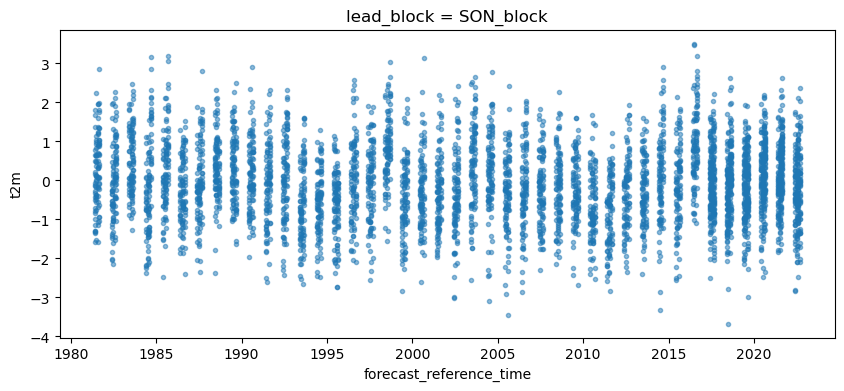

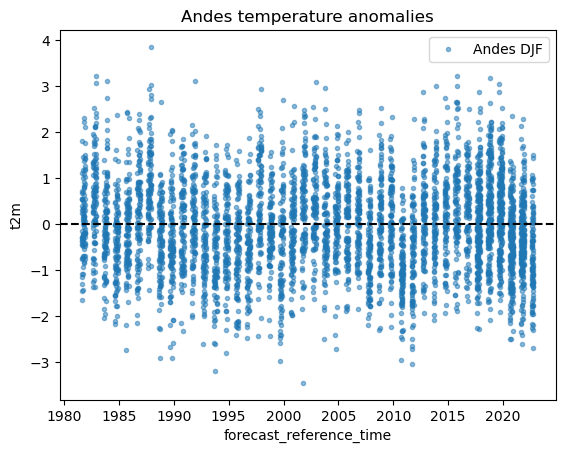

In [32]:
plt.figure(figsize=(10, 4))

t_Andes_ssavg_SON["t2m"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none",
    label="Andes SON",alpha=0.5
)
plt.show()

t_Andes_ssavg_DJF["t2m"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none",
    label="Andes DJF", alpha=0.5
)

plt.axhline(0, color="black", linestyle="dashed")
plt.legend()
plt.title("Andes temperature anomalies")
plt.show()

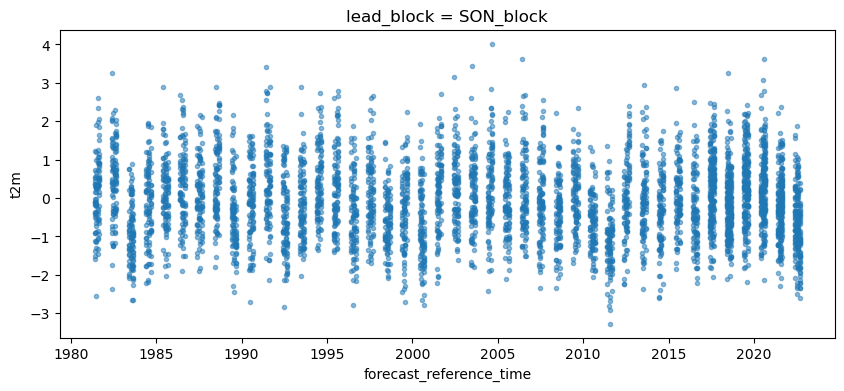

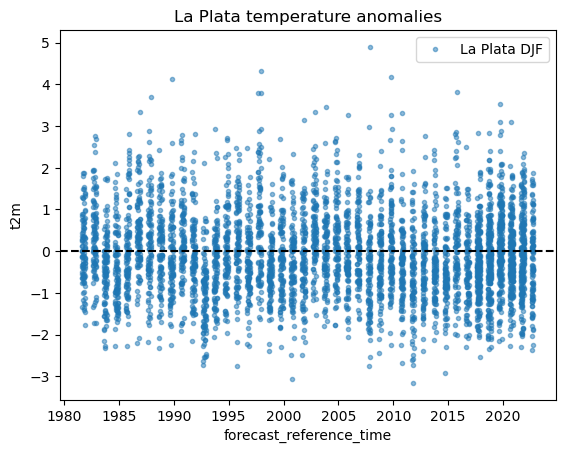

In [33]:
plt.figure(figsize=(10, 4))

t_LaPlata_ssavg_SON["t2m"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none",
    label="La Plata SON",alpha=0.5
)
plt.show()

t_LaPlata_ssavg_DJF["t2m"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none",
    label="La Plata DJF",alpha=0.5
)

plt.axhline(0, color="black", linestyle="dashed")
plt.legend()
plt.title("La Plata temperature anomalies")
plt.show()

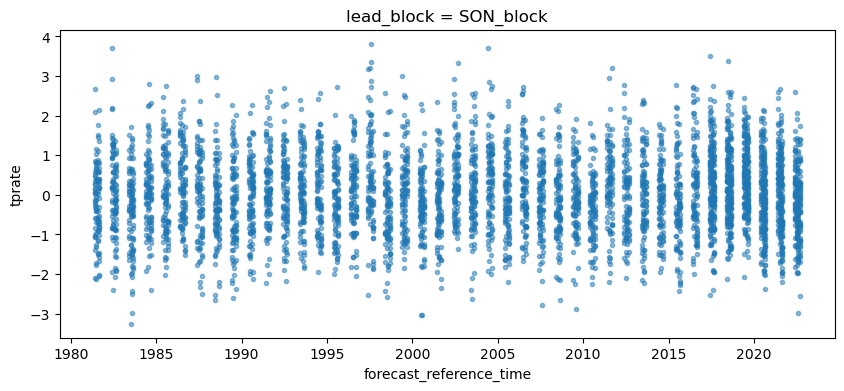

In [ ]:
plt.figure(figsize=(10, 4))

pr_era_Andes_ssavg_SON["tprate"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none",
    label="Andes SON",alpha=0.5
)
plt.show()
pr_era_Andes_ssavg_DJF["tprate"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none",
    label="Andes DJF",
    alpha=0.5
)

plt.axhline(0, color="black", linestyle="dashed")
plt.legend()
plt.title("Andes precipitation-rate anomalies")
plt.show()

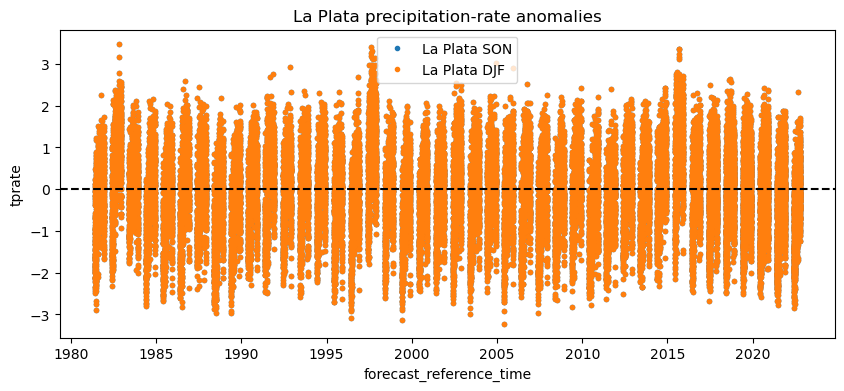

In [ ]:
plt.figure(figsize=(10, 4))

pr_era_LaPlata_ssavg_SON["tprate"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none",
    label="La Plata SON",
    alpha=0.5
)
plt.show()

pr_era_LaPlata_ssavg_DJF["tprate"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none",
    label="La Plata DJF",
    alpha=0.5
)

plt.axhline(0, color="black", linestyle="dashed")
plt.legend()
plt.title("La Plata precipitation-rate anomalies")
plt.show()

In [34]:
pr_era_Andes_ssavg_SON = pr_era_Andes_ssavg_SON.rename({"tprate": "tp"})
pr_era_Andes_ssavg_DJF = pr_era_Andes_ssavg_DJF.rename({"tprate": "tp"})
pr_era_LaPlata_ssavg_SON = pr_era_LaPlata_ssavg_SON.rename({"tprate": "tp"})
pr_era_LaPlata_ssavg_DJF = pr_era_LaPlata_ssavg_DJF.rename({"tprate": "tp"})

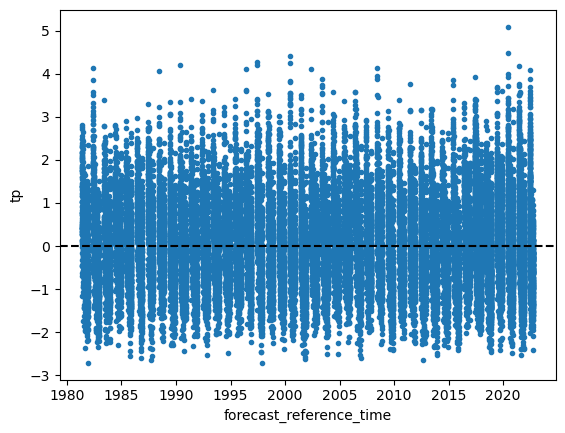

In [35]:
pr_era_Andes_ssavg_DJF["tp"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none"
)
plt.axhline(0, color="black", linestyle="dashed")
plt.show()

In [36]:
save_path='/climca/people/glattus/'
save_folder='Hindcast_data_ready'


##Temp and precip united by region
ds_Andes_SON=xr.merge([t_Andes_ssavg_SON, pr_era_Andes_ssavg_SON])
ds_Andes_DJF=xr.merge([t_Andes_ssavg_DJF, pr_era_Andes_ssavg_DJF])
ds_LP_SON=xr.merge([t_LaPlata_ssavg_SON, pr_era_LaPlata_ssavg_SON])
ds_LP_DJF=xr.merge([t_LaPlata_ssavg_DJF, pr_era_LaPlata_ssavg_DJF])

#reset index
ds_Andes_SON=ds_Andes_SON.reset_index('sample')
ds_Andes_DJF=ds_Andes_DJF.reset_index('sample')
ds_LP_SON=ds_LP_SON.reset_index('sample')
ds_LP_DJF=ds_LP_DJF.reset_index('sample')
display(ds_Andes_SON)
encoding = {var: {"zlib": True, "complevel": 4} for var in ds_Andes_SON.data_vars}
ds_Andes_DJF.to_netcdf(save_path+save_folder+'/Target_vars_Andes_DJF.nc', encoding=encoding)
print('Summer Andes saved')
ds_Andes_SON.to_netcdf(save_path+save_folder+'/Target_vars_Andes_SON.nc', encoding=encoding)
print('Spring Andes saved')
ds_LP_DJF.to_netcdf(save_path+save_folder+'/Target_vars_LP_DJF.nc', encoding=encoding)
print('LP Summer saved')
ds_LP_SON.to_netcdf(save_path+save_folder+'/Target_vars_LP_SON.nc', encoding=encoding)
print('All saved!')


<xarray.Dataset> Size: 3MB
Dimensions:                  (sample: 59568)
Coordinates:
    init_month               (sample) int64 477kB 6 6 6 6 6 6 6 ... 9 9 9 9 9 9
    season                   (sample) object 477kB 'SON' 'SON' ... 'SON' 'SON'
    forecast_reference_time  (sample) datetime64[ns] 477kB 1981-06-01 ... 202...
    number                   (sample) int64 477kB 0 1 2 3 4 5 ... 46 47 48 49 50
Dimensions without coordinates: sample
Data variables:
    t2m                      (sample) float64 477kB dask.array<chunksize=(8,), meta=np.ndarray>
    tp                       (sample) float64 477kB dask.array<chunksize=(8,), meta=np.ndarray>

ENSO and IOD

In [28]:
def ENSO_process(sst):
    'Computation of Nino3.4 index from sst field (ideally already monthly)'

    print('Start ENSO comp')
    sst_nino = select_region(
        sst,
        lat_min=-5,
        lat_max=5,
        lon_min=190,
        lon_max=240
    ) #fixed region
    sst_anomaly_nino=compute_sample_anomaly(sst_nino)
    sst_anomaly_nino_weighted=spatial_average(sst_anomaly_nino)
    
    nino_detr=detrend_across_time(sst_anomaly_nino_weighted)
    print('Detrended ENSO')
    
    sst_anomaly_smoothed = nino_detr.rolling(sample=5, center=True).mean()
    nino34_index=standardize(sst_anomaly_smoothed)
    nino34_index=nino34_index.rename({'sst':'nino34'})
    print('ENSO index computed')
    return nino34_index


from scipy.signal import butter, filtfilt

# Function to apply a low-pass filter (removes >7-year variations)

def lowpass_filter(da, cutoff=1/7, fs=12):
    nyq=fs/2
    wn=cutoff/nyq #standardising my input frequency with nyquist
    # Design the Butterworth filter
    b, a = butter(N=6, Wn=wn, btype='high', fs=fs) 
    #actually it is high pass because low frequency signal acts on long timescales

    # Define a function to apply the filter on 1D time series
    def filter_1d(x):
        if np.any(np.isnan(x)):  # Handle NaNs
            x = np.nan_to_num(x, nan=np.nanmean(x))  # Replace NaNs with mean
        return filtfilt(b, a, x)

    # Apply the filter along the 'time' dimension
    filtered_da = xr.apply_ufunc(
        filter_1d, 
        da, 
        input_core_dims=[["sample"]],  # Apply only along 'sample'
        output_core_dims=[["sample"]],
        vectorize=True  # Ensures it works for each lat/lon point
    )

    return filtered_da

# Function to apply a 3-month running mean
def running_mean(da, window=3):
    return da.rolling(time=window, center=True).mean()

def IOD_process(sst):
    ##modify to adapt worklfow of julia
    '''Computation procedure for IOD index'''
    print('Start IOD comp')
    sst_io_eastweighted=select_region(sst, lat_min=-10, 
                                      lat_max=0,
                                      lon_min=90,
                                      lon_max=110)
    sst_io_westweighted=select_region(sst, lat_min=-10,
                                      lat_max=10,
                                      lon_max=70,
                                      lon_min=50)
   
    #weight by lat and spatial avg after anomaly comp
    sst_anom_ioe=spatial_average(compute_sample_anomaly(sst_io_eastweighted))
    sst_anom_iow=spatial_average(compute_sample_anomaly(sst_io_westweighted))
    print('Anomaly computed')
    #detrend
    ioe_detr=detrend_across_time(sst_anom_ioe).compute()
    iow_detr=detrend_across_time(sst_anom_iow).compute()

    #filter high freqs
    print('Start lowpass')
    ioe_filtered=lowpass_filter(ioe_detr)
    iow_filtered=lowpass_filter(iow_detr)
    #smooth and compute IOD index
    iode_smoothed=ioe_filtered.rolling(sample=3, center=True).mean()
    iodw_smoothed=iow_filtered.rolling(sample=3, center=True).mean()
    iod_index=iodw_smoothed-iode_smoothed
    iod_index_ssavg=standardize(iod_index).rename({'sst':'iod_index'})
    print('IOD index computed')
    return iod_index_ssavg

In [29]:
#use SON_mean and DJF_mean?
sst_SON=SON_mean[['sst']]
sst_DJF=DJF_mean[['sst']]
nino_SON=ENSO_process(sst_SON)
nino_DJF=ENSO_process(sst_DJF)


Start ENSO comp
Detrended ENSO
ENSO index computed
Start ENSO comp
Detrended ENSO
ENSO index computed


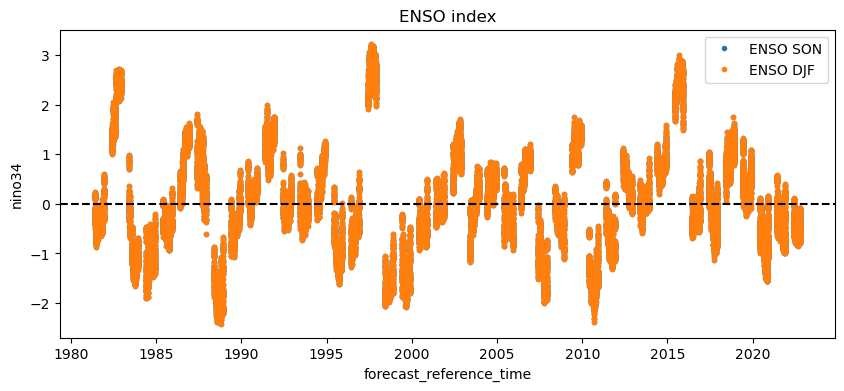

In [ ]:
plt.figure(figsize=(10, 4))

nino_SON["nino34"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none",
    label="ENSO SON"
)
plt.show()

nino_DJF["nino34"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none",
    label="ENSO DJF"
)

plt.axhline(0, color="black", linestyle="dashed")
plt.legend()
plt.title("ENSO index")
plt.show()

Start IOD comp
Anomaly computed
Start lowpass
IOD index computed


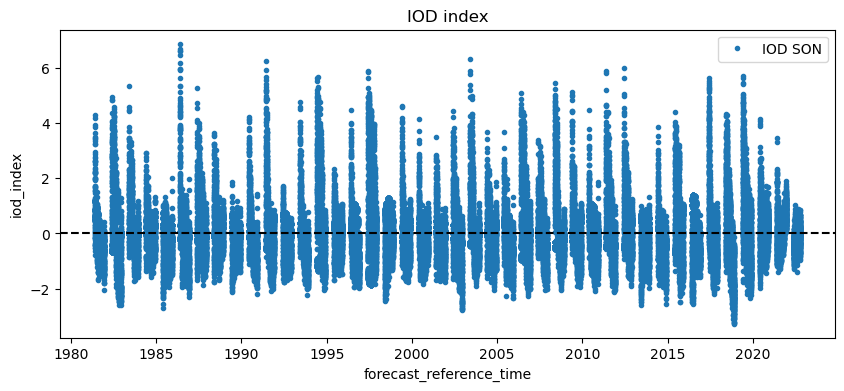

In [31]:
##IOD
IOD_SON=IOD_process(sst_SON)
plt.figure(figsize=(10, 4))

IOD_SON["iod_index"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none",
    label="IOD SON"
)

plt.axhline(0, color="black", linestyle="dashed")
plt.legend()
plt.title("IOD index")
plt.show()

In [33]:
## save ocean drivers in nc file
save_path='/climca/people/glattus/'
save_folder='Hindcast_data_ready'

ds_ocean_SON=xr.merge([IOD_SON, nino_SON])
ds_ocean_SON=ds_ocean_SON.reset_index('sample')
encoding_ocean = {var: {"zlib": True, "complevel": 4} for var in ds_ocean_SON.data_vars}
ds_ocean_SON.to_netcdf(save_path+save_folder+'/ENSO_IOD_SON.nc', encoding=encoding_ocean)

IOBW

In [34]:
def plot_eof1(Vt, X_2d, title="EOF1 pattern"):
    eof1 = Vt[0, :]

    eof1_map = xr.DataArray(
        eof1,
        coords={"space": X_2d.space},
        dims=["space"],
        name="EOF1"
    ).unstack("space")

    eof1_map.plot()
    plt.title(title)
    plt.show()

    return eof1_map

def plot_pc1(pc1_ts, title="PC1 time series"):
    pc1_ts.plot()
    plt.title(title)
    plt.show()

In [35]:
def IOBW_process(sst):

    # 1. Select Indian Ocean region
    sst_io_whole = select_region(
        sst,
        lat_max=26,
        lat_min=-26,
        lon_max=120,
        lon_min=30
    ).sortby("latitude", ascending=True)

    # 2. Anomaly
    sst_anom = compute_sample_anomaly(sst_io_whole)
    print("Anomaly computed")

    # 3. Detrend
    sst_detr = detrend_across_time(sst_anom)

    # 4. Latitude weighting (IMPORTANT: apply on grid, not sample)
    sst_weighted = weight_by_latitude(sst_detr)
    print('Weighted by latitude')
    X = sst_weighted["sst"]

    X_2d = X.stack(space=("latitude", "longitude"))
    X_2d = X_2d.transpose("sample", "space")
    X_2d = X_2d.fillna(np.nanmean(X_2d))

    print("Performing PCA...")

    # 7. SVD / PCA
    U, S, Vt = perform_svd(X_2d.values)

    print(U.shape, S.shape, Vt.shape)
    eof1_map = plot_eof1(Vt, X_2d)

    # 8. PC1 time series
    PC1 = U[:, 0] * S[0]

    PC1_ts = xr.DataArray(
        PC1,
        coords={"sample": X_2d.sample},
        dims=["sample"],
        name="IOBW"
    )

    # 9. Sign convention
    PC1_ts = -PC1_ts

    # 10. Standardization
    IOBW_index = standardize(PC1_ts)
    #plot_pc1(IOBW_index)
    
    print("PCA finished")

    return IOBW_index

In [1]:
IOBW_index=IOBW_process(sst_DJF)

NameError: name 'IOBW_process' is not defined

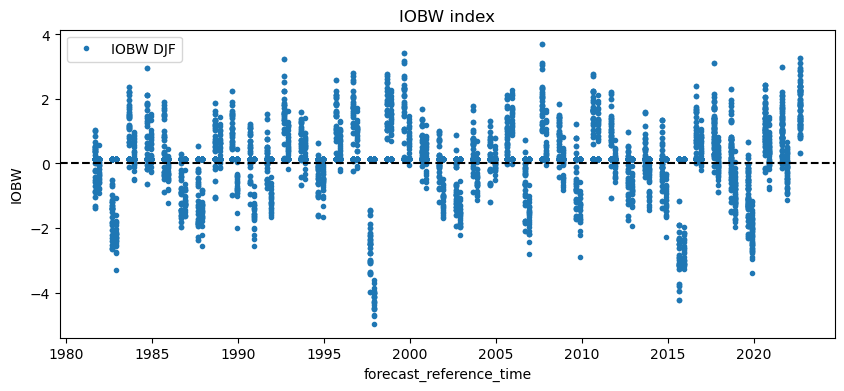

In [ ]:
plt.figure(figsize=(10, 4))

IOBW_index.plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none",
    label="IOBW DJF"
)

plt.axhline(0, color="black", linestyle="dashed")
plt.legend()
plt.title("IOBW index")
plt.show()

In [ ]:
ds_ocean_DJF=xr.merge([IOBW_index, nino_DJF])
ds_ocean_DJF=ds_ocean_DJF.reset_index('sample')
encoding_ocean_DJF = {var: {"zlib": True, "complevel": 4} for var in ds_ocean_DJF.data_vars}
ds_ocean_DJF.to_netcdf(save_path+save_folder+'/ENSO_IOB_DJF.nc', encoding=encoding_ocean_DJF)

SAM

In [ ]:
def SAM_process(zg):

    # 1. region selection
    zg_whole = select_region(
        zg,
        lat_max=-20,
        lat_min=-90,
        lon_max=360,
        lon_min=0
    )

    # 2. anomaly
    zg_anom = compute_sample_anomaly(zg_whole)
    print("Anomaly computed")

    # 3. latitude weighting
    zg_weighted = weight_by_latitude(zg_anom)['z']
    print("Weighted by latitude")

    # 4. PCA matrix (sample × space)
    X_2d = zg_weighted.stack(space=("latitude", "longitude"))
    X_2d = X_2d.transpose("sample", "space")

    # IMPORTANT FIX: do NOT fill with global mean
    X_2d = X_2d.fillna(0)

    print("Performing PCA...")

    # 5. DIRECT SVD (not covariance matrix)
    U, S, Vt = perform_svd(X_2d.values)

    print(U.shape, S.shape, Vt.shape)

    # 6. SAM index (PC1)
    SAM = U[:, 0] * S[0]

    SAM_da = xr.DataArray(
        SAM,
        coords={"sample": X_2d.sample},
        dims=["sample"],
        name="SAM"
    )

    # OPTIONAL sign convention
    SAM_da = -SAM_da

    print("PCA finished")

    # ======================================================
    # 7. ZONAL DECOMPOSITION (kept your logic, unchanged idea)
    # ======================================================

    SAM_zonal_mean = compute_zonal_mean(SAM_da)

    SAM_sym = make_zonal_mean_map(SAM_zonal_mean, zg_anom)
    SAM_asym = SAM_da - SAM_sym

    # 8. regression diagnostics
    SAM_sym_coefficient = regress_onto_zonal_mean_map(zg_anom, SAM_sym)
    plot_regression_coefficients(zg_anom['sample'], SAM_sym_coefficient)

    SAM_asym_coefficient = regress_onto_zonal_mean_map(zg_anom, SAM_asym)
    plot_regression_coefficients(zg_anom['sample'], SAM_asym_coefficient)

    # 9. output arrays
    A_SAM_da = xr.DataArray(
        SAM_asym_coefficient,
        coords={'sample': zg_anom['sample'].values},
        dims=['sample'],
        name='A_SAM'
    )

    S_SAM_da = xr.DataArray(
        SAM_sym_coefficient,
        coords={'sample': zg_anom['sample'].values},
        dims=['sample'],
        name='S_SAM'
    )

    return {
        'SAM': SAM_da,
        'SAM_zonal_mean': SAM_zonal_mean,
        'SAM_sym': SAM_sym,
        'SAM_asym': SAM_asym,
        'SAM_sym_coefficient': S_SAM_da,
        'SAM_asym_coefficient': A_SAM_da
    }

In [ ]:
display(SON_z500_mean)

In [ ]:
##! this cell runs forever as the PCA matrix is huge af
SAM_dict_SON=SAM_process(SON_z500_mean)

SPV and Vortex breakdown date

In [25]:
#SON_u50, DJF_u50
print(SON_u50_mean)

<xarray.Dataset> Size: 16GB
Dimensions:                  (sample: 59568, latitude: 181, longitude: 360)
Coordinates:
    pressure_level           float64 8B 50.0
  * latitude                 (latitude) float64 1kB 90.0 89.0 ... -89.0 -90.0
  * longitude                (longitude) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
  * sample                   (sample) object 477kB MultiIndex
  * init_month               (sample) int64 477kB 6 6 6 6 6 6 6 ... 9 9 9 9 9 9
  * season                   (sample) object 477kB 'SON' 'SON' ... 'SON' 'SON'
  * forecast_reference_time  (sample) datetime64[ns] 477kB 1981-06-01 ... 202...
  * number                   (sample) int64 477kB 0 1 2 3 4 5 ... 46 47 48 49 50
Data variables:
    u                        (sample, latitude, longitude) float32 16GB dask.array<chunksize=(8, 46, 90), meta=np.ndarray>


In [26]:
def SPV_process(ds_50):
    ### Stratospheric zonal winds


    # polar vortex following kretschmer which follows byrne 2019
    polar_vortex =  select_region(ds_50, lat_min=-65, lat_max=-55, lon_min=0, lon_max=360)

    #compute anomaly (#climatologicl mean!!!), weight by lat and average for every gridpoint
    polar_vortex_an=compute_sample_anomaly(polar_vortex)
    polar_vortex_space=spatial_average(polar_vortex_an)
    

    #detrend
    polar_vortex_detr=detrend_across_time(polar_vortex_space)
    print('Detrended')
    #polar_vortex_detr = polar_vortex_detr.chunk({"sample": -1}).compute()
    #print('Dasked array computed!')
    #smoothen
    vortex_smoothed = polar_vortex_detr.sortby("forecast_reference_time")

    vortex_smoothed = vortex_smoothed.rolling(sample=3, center=True).mean()

    #normalise
    SPV_index=standardize(vortex_smoothed)
    print('SPV index is ready!')
    return SPV_index

#find breakdown date
def compute_crossings(u_series):

    below = u_series < 10

    crossing = (~below.shift(sample=1, fill_value=False)) & below

    return crossing.compute()

def find_breakdown_date(u_series, crossing): 
    """ u_series: 1D DataArray (time for one year) returns: datetime or NaT """ 

    mask = crossing

    if mask.any():
        return u_series["forecast_reference_time"].where(mask, drop=True)[-1].values
    else:
        return np.datetime64("NaT")
    
def find_breakdown_date_fast(u_series):

    below = (u_series.values < 10)

    # numpy shift (fast, no xarray overhead)
    crossing = (~np.roll(below, 1)) & below
    crossing[0] = False  # fix wraparound artifact
    print('Crossings computed')
    idx = np.where(crossing)[0]

    if len(idx) > 0:
        return u_series["forecast_reference_time"].values[idx[-1]]
    else:
        return np.datetime64("NaT")

def plot_VB_dates(breakdown_dates):
    dates = pd.to_datetime(breakdown_dates.values)
    years = breakdown_dates["year"].values

    valid = ~pd.isna(dates)
    dates = dates[valid]
    years = years[valid]

    # sort chronologically
    order = np.argsort(dates)
    dates = dates[order]
    years = years[order]

    def wrapped_day(d):
        # shift year so Nov–Feb becomes continuous
        base_year = d.year if d.month >= 11 else d.year - 1
        start = pd.Timestamp(year=base_year, month=11, day=1)
        return (d - start).days


    y = np.array([wrapped_day(d) for d in dates])

    ##add problematic years here as well
    x_pos = [2002, 2020,2003,2019]
    y_pos = [y[years == x][0] for x in x_pos]

    plt.figure(figsize=(10,5))

    # main line
    plt.plot(years, y, color="black", linewidth=2)
    plt.plot(x_pos, y_pos, 'o', color='red', markersize=8, label='Problematic Years')
    # points
    plt.scatter(years, y, color="black", s=30, zorder=3)

    plt.xlabel("Year")
    plt.ylabel("Breakdown date")
    plt.title("Vortex Breakdown Index")

    tick_dates = [
        pd.Timestamp("2001-11-01"),
        pd.Timestamp("2001-11-21"),
        pd.Timestamp("2001-12-11"),
        pd.Timestamp("2002-01-01"),
        pd.Timestamp("2002-01-11")
    ]

    tick_pos = np.array([wrapped_day(d) for d in tick_dates])

    plt.yticks(
        tick_pos,
        [d.strftime("%-d %b") for d in tick_dates]
    )
    plt.axhline(tick_pos[1], linestyle=":", color="blue", alpha=0.6)
    plt.axhline(tick_pos[2], linestyle=":", color="gray", alpha=0.6)
    plt.axhline(tick_pos[3], linestyle=":", color="red", alpha=0.6)
    plt.grid(alpha=0.3)
    plt.show()

def VB_date_process(ds_50):
    'Input must be combined season array since VB can be in spring or summer'
    #zonal mean
    u_zonal = ds_50.mean(dim="longitude")
    #interpolate values to -60°S
    u_60S = u_zonal.interp(latitude=-60)
    
    #rolling window
    u_60_roll = u_60S.rolling(sample=5, center=True).mean()

    # ensure correct grouping
    u_60_roll = u_60_roll.assign_coords(
        vortex_year = u_60_roll["forecast_reference_time"].dt.year
        + (u_60_roll["forecast_reference_time"].dt.month >= 7)
    )
    print('Compute dasked array!')
    u_60_roll_ready=u_60_roll.compute()
    print('Start finding breakdown date')
    years = np.unique(u_60_roll_ready["vortex_year"])

    breakdown_dates = []
    #crossing_all = compute_crossings(u_60_roll)
    #print('Crossings computed')
    
    for year in years:

        u_year = u_60_roll_ready.where(u_60_roll_ready["vortex_year"] == year, drop=True)

        #crossing_year = crossing_all.where(u_60_roll["vortex_year"] == year, drop=True)

        date = find_breakdown_date_fast(u_year)

        breakdown_dates.append(date)

    print('Found breakdown date')
    breakdown_dates = xr.DataArray(
        breakdown_dates,
        coords={"year": years},
        dims=["year"],
        name="vortex_breakdown_date")
    
    plot_VB_dates(breakdown_dates)

    #convert day to DOY
    breakdown_doy = breakdown_dates.dt.dayofyear

    #check the strong SSW years
    #SSWs were in 2002 and 2019, first look at values for those years
    print('2002:', breakdown_doy.sel(year=2002).values)
    print('2003:', breakdown_doy.sel(year=2003).values)
    print('2019:', breakdown_doy.sel(year=2019).values)
    print('2020:', breakdown_doy.sel(year=2020).values)
    
    mask = ~breakdown_doy['year'].isin([2002, 2003, 2019, 2020])
    breakdown_doy_masked = breakdown_doy.where(mask)

    #detrend and standardise as last steps
    VB_detr=detrend_across_time(breakdown_doy_masked)
    VB_index=standardize(VB_detr)

    return VB_index



In [27]:
spv_index_SON=SPV_process(SON_u50_mean[['u']])
#spv_index_DJF=SPV_process(DJF_u50_mean[['u']]) #if needed temporarily too?


Detrended
SPV index is ready!


In [28]:
#daily data needed here!!!
#VB_index=VB_date_process(SON_DJF_u50_mean[['u']])

In [28]:
spv_index_SON['u']

<xarray.DataArray 'u' (sample: 59568)> Size: 477kB
dask.array<truediv, shape=(59568,), dtype=float64, chunksize=(9,), chunktype=numpy.ndarray>
Coordinates:
    pressure_level           float64 8B 50.0
  * sample                   (sample) object 477kB MultiIndex
  * init_month               (sample) int64 477kB 6 6 6 6 6 6 6 ... 9 9 9 9 9 9
  * season                   (sample) object 477kB 'SON' 'SON' ... 'SON' 'SON'
  * forecast_reference_time  (sample) datetime64[ns] 477kB 1981-06-01 ... 202...
  * number                   (sample) int64 477kB 0 1 2 3 4 5 ... 46 47 48 49 50

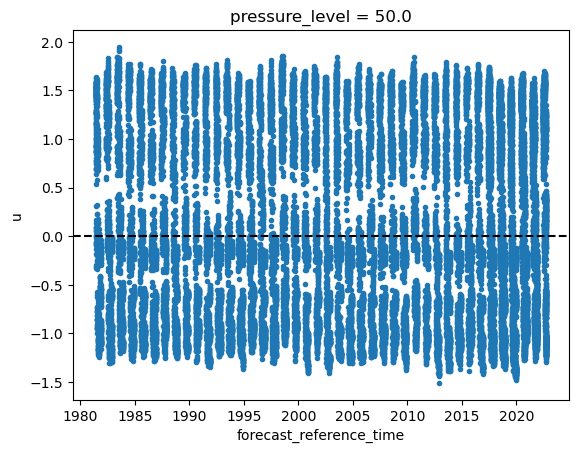

In [30]:
spv_index_SON["u"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none"
)
plt.axhline(0, color="black", linestyle="dashed")
plt.show()

#spv_index_DJF["u"].plot(
#    x="forecast_reference_time",
#    marker=".",
#    linestyle="none"
#)
#plt.axhline(0, color="black", linestyle="dashed")
#plt.show()

In [29]:
ds_strato_SON=spv_index_SON.reset_index('sample')
print(ds_strato_SON['u'].chunk({'sample':-1}))
print(ds_strato_SON.data_vars)
print(ds_strato_SON.chunks)

<xarray.DataArray 'u' (sample: 59568)> Size: 477kB
dask.array<rechunk-merge, shape=(59568,), dtype=float64, chunksize=(59568,), chunktype=numpy.ndarray>
Coordinates:
    pressure_level           float64 8B 50.0
    init_month               (sample) int64 477kB dask.array<chunksize=(59568,), meta=np.ndarray>
    season                   (sample) object 477kB dask.array<chunksize=(59568,), meta=np.ndarray>
    forecast_reference_time  (sample) datetime64[ns] 477kB dask.array<chunksize=(59568,), meta=np.ndarray>
    number                   (sample) int64 477kB dask.array<chunksize=(59568,), meta=np.ndarray>
Dimensions without coordinates: sample
Data variables:
    u        (sample) float64 477kB dask.array<chunksize=(9,), meta=np.ndarray>
Frozen({'sample': (9, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8,

In [30]:
save_path='/climca/people/glattus/'
save_folder='Hindcast_data_ready'

ds_strato_SON= spv_index_SON#xr.merge([spv_index_SON]) # , VB_index])
ds_strato_SON=ds_strato_SON.reset_index('sample').chunk({"sample": -1})   # one chunk
encoding_strato_SON = {var: {"zlib": True, "complevel": 4} for var in ds_strato_SON.data_vars}
ds_strato_SON.to_netcdf(save_path+save_folder+'/SPV_SON.nc', encoding=encoding_strato_SON)




/tmp/ipykernel_1309597/986758838.py:7: SerializationWarning: variable season has data in the form of a dask array with dtype=object, which means it is being loaded into memory to determine a data type that can be safely stored on disk. To avoid this, coerce this variable to a fixed-size dtype with astype() before saving it.
  ds_strato_SON.to_netcdf(save_path+save_folder+'/SPV_SON.nc', encoding=encoding_strato_SON)


In [ ]:
ds_strato_DJF=spv_index_DJF#xr.merge([spv_index_DJF]) #, VB_index])
ds_strato_DJF=ds_strato_DJF.reset_index('sample').chunk({"sample": -1})   # one chunk
encoding_strato_DJF = {var: {"zlib": True, "complevel": 4} for var in ds_strato_DJF.data_vars}
ds_strato_DJF.to_netcdf(save_path+save_folder+'/SPV_DJF.nc', encoding=encoding_strato_DJF)

# BORDER TO OLD CODE

In [ ]:
#edj following byrne 2017
#EDJ = ua.sel(pressure_level=850).u.drop('pressure_level').sel(time=slice('1950','2024'),lat=slice(-70,-35))
#edj_zonal_avg=EDJ.mean(dim='lon')
#display(edj_zonal_avg)
#find latitude at time t where wind is strongest
max_lat=edj_zonal_avg.idxmax(dim='lat')
max_lat_smoothed=max_lat.rolling(time=5, center=True).mean()
# find corresponding wind speed for the max latitude
edj_max=edj_zonal_avg.sel(lat=max_lat, method='nearest')

#compute anomaly
edj_max_an=compute_anomaly(edj_max)

#weight by lat
edj_max_wght=weight_by_latitude(edj_max_an)

#detrend
p_jet=edj_max_wght.polyfit(dim='time', deg=1, skipna=False)
jet_fit=xr.polyval(edj_max_wght['time'], p_jet.polyfit_coefficients)
edj_detr=edj_max_wght-jet_fit

#smoothen
edj_smooth=running_mean(edj_detr)

#normalise
edj_index=edj_smooth/edj_smooth.std(dim='time')
#display(edj_index)
#extract seasonal data
max_lat_DJF=extract_seasonal_data(max_lat_smoothed,[12,1,2])
max_lat_SON=extract_seasonal_data(max_lat_smoothed,[9,10,11])

edj_index_DJF=extract_seasonal_data(edj_index,[12,1,2])
edj_index_SON=extract_seasonal_data(edj_index,[9,10,11])

#seasonal average and standardise again
#edj speed
edj_index_ssavg_DJF=stdize_ssavg(seasonal_average(shift_december(edj_index_DJF)))
edj_index_ssavg_SON=stdize_ssavg(seasonal_average(edj_index_SON))
#max lat
max_lat_ssavg_DJF=stdize_ssavg(seasonal_average(shift_december(max_lat_DJF)))
max_lat_ssavg_SON=stdize_ssavg(seasonal_average(max_lat_SON))
max_lat_nostd_DJF=seasonal_average(shift_december(max_lat_DJF))
max_lat_nostd_SON=seasonal_average(max_lat_SON)

edj_index_ssavg_DJF.plot(label='DJF')
edj_index_ssavg_SON.plot(label='SON')
plt.hlines(np.mean(edj_index_ssavg_DJF),xmin=1950, xmax=2025, color='red', linestyle='dashed')
plt.hlines(np.mean(edj_index_ssavg_SON),xmin=1950, xmax=2025, color='red', linestyle='dashed')
plt.legend()
plt.title('EDJ Index')
plt.show()
max_lat_ssavg_DJF.plot(label='DJF')
max_lat_ssavg_SON.plot(label='SON')
plt.hlines(np.mean(max_lat_ssavg_DJF),xmin=1950, xmax=2025, color='red', linestyle='dashed')
plt.hlines(np.mean(max_lat_ssavg_DJF),xmin=1950, xmax=2025, color='red', linestyle='dashed')
plt.legend()
plt.title('Max lat standardised')
plt.show()
max_lat_nostd_DJF.plot(label='DJF')
max_lat_nostd_SON.plot(label='SON')
plt.title('Max lat')
plt.legend()
plt.show()
polar_vortex.u

plt.scatter(polar_vortex.time('month'==12), polar_vortex.u.mean(dim=['lat', 'lon']))

SAM

In [ ]:
### Geopotential height
zg = xr.open_dataset('data/era5_zg_2.5x2.5.nc')
display(zg)
zg = zg.rename({'valid_time': 'time'})
zg = zg.sel(pressure_level=500).z.drop('pressure_level').sel(time=slice('1950','2024'),lat=slice(-90,-20))
#display(zg['lat'])

# if one wants to look at it seasonally:
zg_DJF=extract_seasonal_data(zg,[12,1,2])
zg_SON=extract_seasonal_data(zg,[9,10,11])

# Compute monthly climatology --> each month has one average
zg_climatology = zg.groupby('time.month').mean('time')

# Compute monthly anomalies
zg_anomalies = zg.groupby('time.month') - zg_climatology
zg_anomalies_DJF=compute_anomaly(zg_DJF)
zg_anomalies_SON=compute_anomaly(zg_SON)

# Compute PCs
zg_weighted = weight_by_latitude(zg_anomalies)
reshaped_zg = reshape_to_2d(zg_weighted)

zg_weighted_DJF = weight_by_latitude(zg_anomalies_DJF)
reshaped_zg_DJF = reshape_to_2d(zg_weighted_DJF)
zg_weighted_SON = weight_by_latitude(zg_anomalies_SON)
reshaped_zg_SON = reshape_to_2d(zg_weighted_SON)

def SAM_procedure(reshaped_zg, zg_anomalies):
    cov_matrix = compute_covariance_matrix(reshaped_zg)
    U, S, Vt = perform_svd(cov_matrix) # all have shape 1584 in every dim, 
    #S has singular/eigenvalues and Vt has eigenvectors

    # Define SAM as first principal component
    SAM = plot_first_principal_component(reshaped_zg, Vt)

    # Decompose SAM in symmetric and asymmetric
    SAM_zonal_mean = compute_zonal_mean(SAM) #avg over all lon
    SAM_sym = make_zonal_mean_map(SAM_zonal_mean, zg_anomalies) #map the avg from above onto the whole field
    SAM_asym = SAM - SAM_sym #difference between map and first PCA gives 'anomaly'

    SAM_sym_coefficient = regress_onto_zonal_mean_map(zg_anomalies, SAM_sym)
    plot_regression_coefficients(zg_anomalies['time'], SAM_sym_coefficient)

    SAM_asym_coefficient = regress_onto_zonal_mean_map(zg_anomalies, SAM_asym)
    plot_regression_coefficients(zg_anomalies['time'], SAM_asym_coefficient)
    d={'SAM':SAM, 'SAM_zonal_mean':SAM_zonal_mean, 'SAM_sym':SAM_sym, 'SAM_asym':SAM_asym, \
       'SAM_sym_coefficient':SAM_sym_coefficient, 'SAM_asym_coefficient':SAM_asym_coefficient}
    return (d)

SAM_total=SAM_procedure(reshaped_zg, zg_anomalies)
SAM=SAM_total['SAM']
A_SAM_index=SAM_total['SAM_asym_coefficient']
S_SAM_index=SAM_total['SAM_sym_coefficient']

#weight by lat again? --> no
#detrend? --> no
A_SAM_detr=A_SAM_index
S_SAM_detr=S_SAM_index
#normalise
A_SAM_avg=(A_SAM_detr-A_SAM_detr.mean())/A_SAM_detr.std()
S_SAM_avg=(S_SAM_detr-S_SAM_detr.mean())/S_SAM_detr.std()

#EOFs for the both seasons
print('DJF')
SAM_DJF=SAM_procedure(reshaped_zg_DJF, zg_anomalies_DJF)
print('SON')
SAM_SON=SAM_procedure(reshaped_zg_SON, zg_anomalies_SON)

#extract regression coefficient
A_SAM_DJF_index=SAM_DJF['SAM_asym_coefficient']

S_SAM_DJF_index=SAM_DJF['SAM_sym_coefficient']


A_SAM_SON_index=SAM_SON['SAM_asym_coefficient']

S_SAM_SON_index=SAM_SON['SAM_sym_coefficient']

In [ ]:
def make_xarray_again(array, zg_anomalies_DJF, xname):
    A_SAM_DJF_da = xr.DataArray(
        array, 
        coords={'time': zg_anomalies_DJF['time'].values}, 
        dims=['time'],
        name=xname
            )
    return A_SAM_DJF_da

A_SAM_DJF_da=make_xarray_again(A_SAM_DJF_index, zg_anomalies_DJF, 'A_SAM')
A_SAM_SON_da=make_xarray_again(A_SAM_SON_index, zg_anomalies_SON, 'A_SAM')
S_SAM_DJF_da=make_xarray_again(S_SAM_DJF_index, zg_anomalies_DJF, 'S_SAM')
S_SAM_SON_da=make_xarray_again(S_SAM_SON_index, zg_anomalies_SON, 'S_SAM')

#seasonal averages and standardise again
A_SAM_ssavg_DJF=stdize_ssavg(seasonal_average(shift_december(A_SAM_DJF_da)))
A_SAM_ssavg_SON=stdize_ssavg(seasonal_average(shift_december(A_SAM_SON_da)))
S_SAM_ssavg_DJF=stdize_ssavg(seasonal_average(shift_december(S_SAM_DJF_da)))
S_SAM_ssavg_SON=stdize_ssavg(seasonal_average(shift_december(S_SAM_SON_da)))

A_SAM_ssavg_DJF.plot(label='A-SAM DJF')
plt.hlines(np.mean(A_SAM_ssavg_DJF),xmin=1950, xmax=2025, color='red', linestyle='dashed')
S_SAM_ssavg_DJF.plot(label='S-SAM DJF')
plt.hlines(np.mean(S_SAM_ssavg_DJF),xmin=1950, xmax=2025, color='red', linestyle='dashed')
plt.ylabel('Reg coefficient amplitude standardised')
plt.legend()
plt.show()
A_SAM_ssavg_SON.plot(label='A-SAM SON')
plt.hlines(np.mean(A_SAM_ssavg_SON),xmin=1950, xmax=2025, color='red', linestyle='dashed')
S_SAM_ssavg_SON.plot(label='S-SAM SON')
plt.hlines(np.mean(S_SAM_ssavg_SON),xmin=1950, xmax=2025, color='red', linestyle='dashed')
plt.ylabel('Reg coefficient amplitude standardised')
plt.legend()
plt.show()

In [ ]:
#display((A_SAM_ssavg_DJF))

# Gather everything in one pandas dataframe

In [ ]:
def convert_to_pandas(X, name, var1=False):
   # if var1=='time':
        time_list = list(X[var1].values)  # Extract time values correctly
        df = pd.DataFrame({name: X.values}, index=time_list)  # Create DataFrame
    #else: 
     #   time_list=list(max_lat_smoothed[var1].values)
      #  df = pd.DataFrame({name: X}, index=time_list)  # Create DataFrame
        return df

def dataframe_maker(somelist, name_list):
    btw_list=[]
    for i, item in enumerate(somelist):
    #print(item.variables)
        a=convert_to_pandas(item, name_list[i], 'year')
        btw_list.append(a)
        era_DJF_Andes_df=pd.concat(btw_list, axis=1)
    return era_DJF_Andes_df

def exclude_years(df, yearlist):
    df_new=df.drop(year for year in yearlist if year in df.index)
    return df_new

In [ ]:
time_list=list(iod_nino_list_upd[0]['time_bnds'].year.values)
print(time_list)
#SAM still missing
#gather all stuff sorted
###Observations
##Andes
#DJF
obs_DJF_Andes_list=[tas_Andes_ssavg_DJF,pr_Andes_ssavg_DJF['precip'],iod_nino_list_upd[0]['nino34'], \
                        iod_nino_list_upd[2],edj_index_ssavg_DJF,max_lat_ssavg_DJF,max_lat_nostd_DJF, SPV_ssavg_DJF,\
                        A_SAM_ssavg_DJF, S_SAM_ssavg_DJF]
#SON
obs_SON_Andes_list=[tas_Andes_ssavg_SON,pr_Andes_ssavg_SON['precip'],iod_nino_list_upd[1]['nino34'], \
                        iod_nino_list_upd[3],edj_index_ssavg_SON,max_lat_ssavg_SON,max_lat_nostd_SON,SPV_ssavg_SON, \
                   A_SAM_ssavg_SON, S_SAM_ssavg_SON]
##La Plata
#DJF
obs_DJF_LaPlata_list=[tas_LaPlata_ssavg_DJF,pr_LaPlata_ssavg_DJF['precip'],iod_nino_list_upd[0]['nino34'], \
                        iod_nino_list_upd[2],edj_index_ssavg_DJF,max_lat_ssavg_DJF,max_lat_nostd_DJF,SPV_ssavg_DJF, \
                     A_SAM_ssavg_DJF, S_SAM_ssavg_DJF]
#SON
obs_SON_LaPlata_list=[tas_LaPlata_ssavg_SON,pr_LaPlata_ssavg_SON['precip'],iod_nino_list_upd[1]['nino34'], \
                        iod_nino_list_upd[3],edj_index_ssavg_SON,max_lat_ssavg_SON,max_lat_nostd_SON,SPV_ssavg_SON, \
                     A_SAM_ssavg_SON, S_SAM_ssavg_SON]
###ERA5
##Andes
#DJF
era_DJF_Andes_list=[t_Andes_ssavg_DJF['t2m'],pr_era_Andes_ssavg_DJF['tp'],iod_nino_list_upd[0]['nino34'], \
                        iod_nino_list_upd[2],edj_index_ssavg_DJF,max_lat_ssavg_DJF,max_lat_nostd_DJF,SPV_ssavg_DJF, \
                   A_SAM_ssavg_DJF, S_SAM_ssavg_DJF]
#SON
era_SON_Andes_list=[t_Andes_ssavg_SON['t2m'],pr_era_Andes_ssavg_SON['tp'],iod_nino_list_upd[1]['nino34'], \
                        iod_nino_list_upd[3],edj_index_ssavg_SON,max_lat_ssavg_SON,max_lat_nostd_SON,SPV_ssavg_SON, \
                   A_SAM_ssavg_SON, S_SAM_ssavg_SON]
##LaPlata
#DJF
era_DJF_LaPlata_list=[t_LaPlata_ssavg_DJF['t2m'],pr_era_LaPlata_ssavg_DJF['tp'],iod_nino_list_upd[0]['nino34'], \
                        iod_nino_list_upd[2],edj_index_ssavg_DJF,max_lat_ssavg_DJF,max_lat_nostd_DJF,SPV_ssavg_DJF, \
                     A_SAM_ssavg_DJF, S_SAM_ssavg_DJF]
#SON
era_SON_LaPlata_list=[t_LaPlata_ssavg_SON['t2m'],pr_era_LaPlata_ssavg_SON['tp'],iod_nino_list_upd[1]['nino34'], \
                        iod_nino_list_upd[3],edj_index_ssavg_SON,max_lat_ssavg_SON,max_lat_nostd_SON,SPV_ssavg_SON, \
                     A_SAM_ssavg_SON, S_SAM_ssavg_SON]

In [ ]:
name_list1=['t_Andes','precip_Andes','ENSO','IOD','EDJ','EDJ_lat','EDJ_lat_nostd','SPV', 'A_SAM', 'S_SAM']
name_list2=['t_LaPlata','precip_LaPlata','ENSO','IOD','EDJ','EDJ_lat','EDJ_lat_nostd','SPV', 'A_SAM', 'S_SAM']


###Obs
##Andes
#DJF
obs_DJF_Andes_df=dataframe_maker(obs_DJF_Andes_list, name_list1)
#SON
obs_SON_Andes_df=dataframe_maker(obs_SON_Andes_list, name_list1)
##La Plata
#DJF
obs_DJF_LaPlata_df=dataframe_maker(obs_DJF_LaPlata_list, name_list2)
#SON
obs_SON_LaPlata_df=dataframe_maker(obs_SON_LaPlata_list, name_list2)

###ERA5
##Andes
#DJF
era_DJF_Andes_df=dataframe_maker(era_DJF_Andes_list, name_list1)
#SON
era_SON_Andes_df=dataframe_maker(era_SON_Andes_list, name_list1)
##La Plata
#DJF
era_DJF_LaPlata_df=dataframe_maker(era_DJF_LaPlata_list, name_list2)
#SON
era_SON_LaPlata_df=dataframe_maker(era_SON_LaPlata_list, name_list2)
display(obs_DJF_Andes_df)
#plt.plot(obs_SON_LaPlata_df['precip_LaPlata'], 'o') #again precip data starts in 1979

Exclude years and export them as csv

In [ ]:
years=[1950,2025]
df_list=[obs_DJF_Andes_df, obs_SON_Andes_df,obs_DJF_LaPlata_df, obs_SON_LaPlata_df,era_DJF_Andes_df, \
         era_SON_Andes_df, era_DJF_LaPlata_df, era_SON_LaPlata_df]
df_list_dropped=[]
for i, item in enumerate(df_list):
    if i in np.arange(0,len(df_list),2): #every second element is DJF
     #eliminate year 2003 and 2020 from DJF because of SSW
        years.append(2003)
        years.append(2020)
        item_drop=exclude_years(item, years)
    else:
    #eliminate year 2002 and 2019 from SON because of SSW
        years.append(2002)
        years.append(2019)
        item_drop=exclude_years(item, years)
    del years[2:] #reset years to list from above
    df_list_dropped.append(item_drop)
    #probably gonna export the pandas dataframes as csv into data_ready directory
    item_csv=item_drop.to_csv('data_ready/' + str(i)+'.csv')
display(df_list_dropped[0].index, df_list_dropped[1].index)


In [ ]:
print(list([years, 2002]))

# Tried some stuff

In [ ]:
#display(pr_Andes_fix['precip'].values)
time_list=list(max_lat_smoothed['time'].values)
tas_A=convert_to_pandas(tas_Andes_fix, 'tas_Andes', 'time')
tas_LP=convert_to_pandas(tas_LaPlata_fix, 'tas_LaPlata', 'time')
pr_A=convert_to_pandas(pr_Andes_fix['precip'], 'precip_Andes', 'time')
pr_LP=convert_to_pandas(pr_LaPlata_fix['precip'], 'precip_LaPlata', 'time')
edj_df=convert_to_pandas(max_lat_smoothed,'max_lat','time')
SPV_df=convert_to_pandas(SPV_index, 'SPV', 'time')
#display(SPV_df)
SAM_sym_df=pd.DataFrame({'S_SAM':S_SAM_index}, index=time_list)
SAM_asym_df=pd.DataFrame({'A_SAM':A_SAM_index}, index=time_list)
nino_df=convert_to_pandas(nino34_index['nino34'], 'nino34', 'time')
iod_df=convert_to_pandas(iod_index['IOD'], 'IOD', 'time')
big_df=pd.concat([tas_A, tas_LP, pr_A, pr_LP, edj_df, SPV_df, SAM_sym_df, SAM_asym_df, nino_df, iod_df], axis=1)
display(big_df)

## Relationship between EDJ and SAM

In [ ]:

#SAM_df=convert_to_pandas(SAM_zonal_mean, 'time', 'SAM')
df_corr=pd.concat([edj_df, SAM_sym_df, SAM_asym_df], axis=1)
display(df_corr.corr())
model=regplot(df_corr, x='max_lat', y='S_SAM')
plt.show()
model2=regplot(df_corr, x='max_lat', y='A_SAM')
plt.show()
model3=regplot(df_corr, x='A_SAM', y='S_SAM')
plt.show()
#model=sm.OLS(input_map)
#fit=model.fit()
#print(results)
#heatmap(df_corr.corr())

# Correlation between IOD and ENSO

In [ ]:
df_corr=pd.concat([nino_df, iod_df],axis=1).dropna()
display(df_corr)
display(df_corr.corr())
model=regplot(df_corr, x='nino34', y='IOD')
plt.show()
model2=regplot(df_corr, x='IOD', y='nino34')
plt.show()

X1=sm.add_constant(df_corr['nino34'])
Y1=df_corr['IOD']
model=sm.OLS(Y1,X1)
results=model.fit()
display(results.params)
display(results.summary())
Y2=df_corr['nino34']
X2=sm.add_constant(df_corr['IOD'])
model2=sm.OLS(Y2,X2)
results2=model.fit()

display(results2.params)
display(results2.summary())
#apparently sm-ols does not like xarray, convert all to pandas best option???:(